In [1]:
import pandas as pd
import re
import numpy as np
from sklearn.metrics import root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# Load data
vabb = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/01vabb_rnaagecalc-07272025.csv")

# Rename the first column to SampleID
vabb.rename(columns={vabb.columns[0]: "SampleID"}, inplace=True)

# Replace the letter between numbers with an underscore
vabb["SampleID"] = vabb["SampleID"].str.replace(r"(?<=\d)[A-Z]+(?=\d)", "_", regex=True)

# Preview
vabb.head()

,SampleID,DESeq2_adipose_tissue,Pearson_adipose_tissue,Dev_adipose_tissue,deMagalhaes_adipose_tissue,GenAge_adipose_tissue,GTExAge_adipose_tissue,Peters_adipose_tissue,all_adipose_tissue,DESeq2_adrenal_gland,...,Peters_uterus,all_uterus,DESeq2_vagina,Pearson_vagina,Dev_vagina,deMagalhaes_vagina,GenAge_vagina,GTExAge_vagina,Peters_vagina,all_vagina
0,Sample10027_24,97.470795,50.711678,48.271849,42.311492,37.937998,47.605415,24.937594,38.312130,73.955566,...,-57.943475,38.831331,45.702302,27.875332,38.823613,60.522481,39.390420,110.128988,43.162432,13.821477
1,Sample10027_9,100.323219,55.347139,46.015954,40.613549,23.422853,51.845282,34.626861,33.689001,76.516010,...,-44.883085,32.082638,42.695598,28.440104,36.890379,60.420559,6.403906,112.060331,42.390695,11.165722
2,Sample1093_24,97.639568,47.975988,52.018693,38.732554,44.947199,54.906908,25.991309,44.351809,72.692139,...,-63.569095,38.673650,39.985840,20.962379,37.701318,53.944298,-5.959427,115.431633,43.340170,11.187920
3,Sample1093_9,97.884198,49.543841,46.324349,37.711774,40.430513,56.415830,38.877882,41.319735,75.006284,...,-61.740543,34.315874,35.773738,21.406347,36.944908,55.272706,29.423605,114.909467,43.276941,9.337955
4,Sample1124_24,93.322988,42.509450,47.153603,35.852101,27.111422,46.066503,18.657213,33.700761,60.736851,...,-35.058779,28.321220,43.727986,26.034484,42.728473,58.891915,36.709781,103.023645,49.087973,13.078059


In [11]:
# Load phenotype data
pheno_path = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00phenotype/00vabb/00PhenoMeta_trainclock-07272025.csv"
pheno_data = pd.read_csv(pheno_path)

# Create suffixes
suffixes = ["_9", "_24", "_25", "_11"]

# Replicate and modify pheno_data
pheno_data_expanded = pd.concat([
    pheno_data.assign(SampleID="Sample" + pheno_data["SampleID"].astype(str) + suffix)
    for suffix in suffixes
], ignore_index=True)
pheno_data_expanded.head()

,SampleID,Cohort,Sex,PMI,RIN,AgeDeath
0,Sample5205_9,Lieber,Male,29.0,8.4,51
1,Sample5228_9,Lieber,Female,24.5,6.3,58
2,Sample5286_9,Lieber,Female,26.0,6.0,44
3,Sample5287_9,Lieber,Male,28.0,7.7,40
4,Sample5323_9,Lieber,Male,21.5,7.0,35


In [12]:
# Merge on SampleID
merged_df = pd.merge(pheno_data_expanded, vabb, on="SampleID", how="inner")
# Preview result
merged_df.head()

,SampleID,Cohort,Sex,PMI,RIN,AgeDeath,DESeq2_adipose_tissue,Pearson_adipose_tissue,Dev_adipose_tissue,deMagalhaes_adipose_tissue,...,Peters_uterus,all_uterus,DESeq2_vagina,Pearson_vagina,Dev_vagina,deMagalhaes_vagina,GenAge_vagina,GTExAge_vagina,Peters_vagina,all_vagina
0,Sample5205_9,Lieber,Male,29.0,8.4,51,98.979399,58.631939,44.255316,40.361633,...,-59.097454,43.963876,51.171687,36.596403,38.567926,57.057956,25.227871,127.956135,47.407808,22.024076
1,Sample5228_9,Lieber,Female,24.5,6.3,58,108.333410,60.773219,48.039501,40.500279,...,-65.220511,43.315390,47.792059,31.681567,39.486125,57.489420,-10.574932,126.123888,47.680470,15.537507
2,Sample5286_9,Lieber,Female,26.0,6.0,44,106.507340,50.686241,36.957834,43.762614,...,-84.165339,25.757648,34.860308,20.121429,35.161606,57.109346,34.663151,97.678795,39.469604,4.345076
3,Sample5287_9,Lieber,Male,28.0,7.7,40,102.297305,53.753391,54.438922,42.198436,...,-58.382340,50.546308,53.894481,34.481126,41.308928,57.179272,56.182066,133.922059,52.355244,22.530600
4,Sample5323_9,Lieber,Male,21.5,7.0,35,107.360388,70.399739,48.280289,43.623003,...,-75.125888,38.672864,42.497593,26.557731,37.217969,59.280642,56.126465,124.505995,45.798002,13.986897


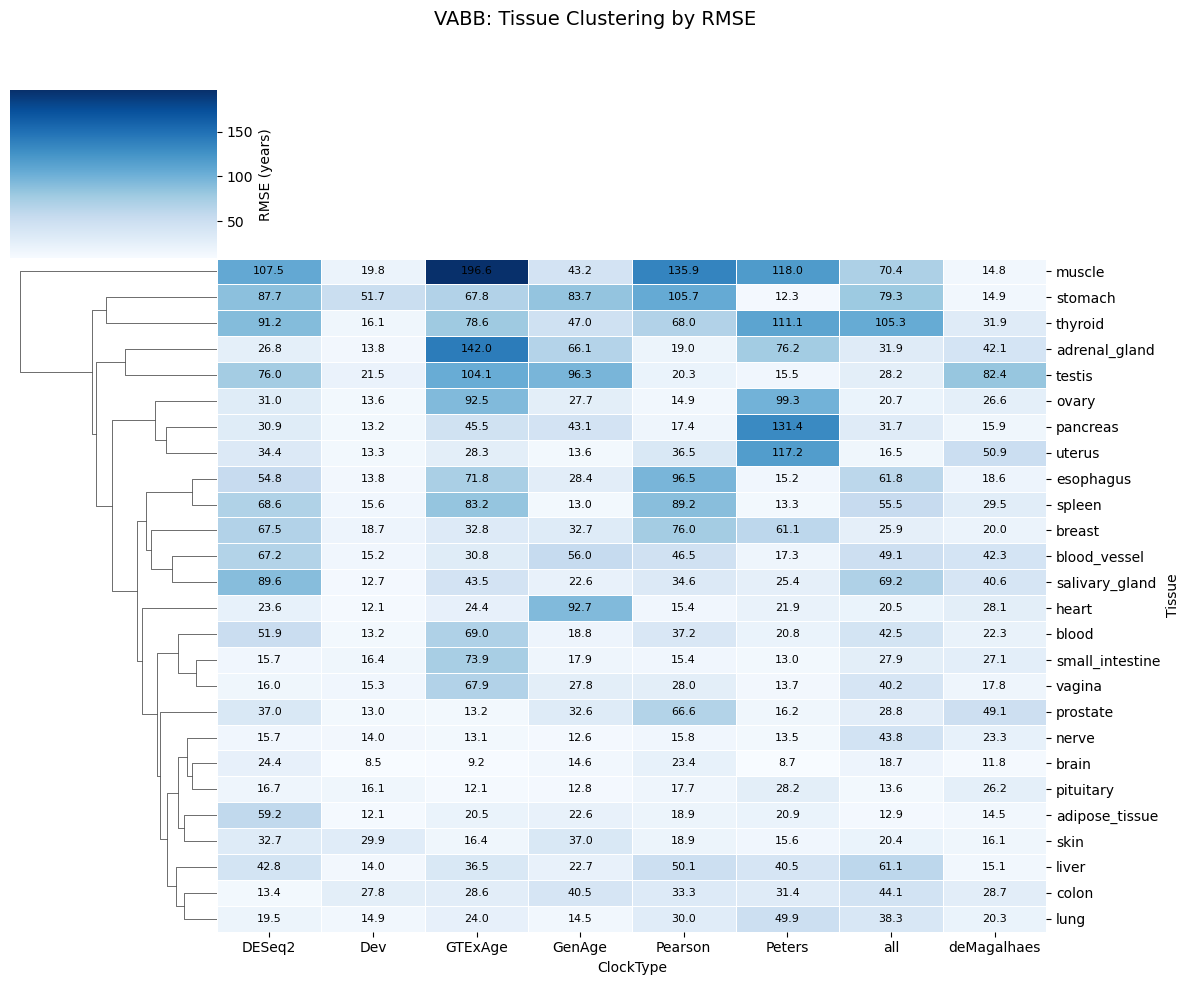

In [30]:
# 1. Define Age column and clock columns
age_col = 'AgeDeath'
clock_cols = merged_df.columns[merged_df.columns.get_loc("AgeDeath")+1:]

# 2. Compute correlation and RMSE
results = []
for col in clock_cols:
    y_true = merged_df[age_col]
    y_pred = merged_df[col]
    corr = y_true.corr(y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    results.append({'Clock': col, 'Correlation': corr, 'RMSE': rmse})

results_df = pd.DataFrame(results)

# 3. Split into tissue and clock
results_df[['ClockType', 'Tissue']] = results_df['Clock'].str.extract(r'^(.*?)_(.+)$')

# 4. Pivot RMSE for clustering
rmse_matrix = results_df.pivot(index='Tissue', columns='ClockType', values='RMSE')

# 5. Plot clustering
# Use a reversed colormap to highlight lower RMSE (darker = lower)
cmap = sns.color_palette("Blues", as_cmap=True)

# 5. Pivot RMSE values into matrix (Tissue x ClockType)
rmse_matrix = results_df.pivot(index='Tissue', columns='ClockType', values='RMSE')

# 6. Create clustermap with low RMSE highlighted
g = sns.clustermap(
    rmse_matrix,
    row_cluster=True,
    col_cluster=False,  # <-- disables clustering of clocks
    metric="euclidean",
    method="average",
    cmap=cmap,
    figsize=(12, 10),
    annot=True,
    fmt=".1f",
    annot_kws={"size": 8, "color": "black"},
    linewidths=0.5,
    cbar_kws={"label": "RMSE (years)"}
)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("VABB: Tissue Clustering by RMSE", fontsize=14)
plt.show()

In [24]:
# loading phenotype data
phenoPath = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/00phenotype/01uthealth/00MetaData_UTHealth_RNAseq-07292025.csv"
phenoData = pd.read_csv(phenoPath)
phenoData.rename(columns={phenoData.columns[0]: "SampleID"}, inplace=True)

# Load data
uthh = pd.read_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/02trans_age-07272025/00uthhealth_rnaagecalc-07272025.csv")
# Rename the first column to SampleID
uthh.rename(columns={uthh.columns[0]: "SampleID"}, inplace=True)

# Merge on SampleID
merged_df2 = pd.merge(phenoData, uthh, on="SampleID", how="inner")
# Preview result
merged_df2

,SampleID,SAB,UTID,Ethnicity,Gender,Age,PMIhrs,RIN_novogene,pH,Cause_of_Death,...,Peters_uterus,all_uterus,DESeq2_vagina,Pearson_vagina,Dev_vagina,deMagalhaes_vagina,GenAge_vagina,GTExAge_vagina,Peters_vagina,all_vagina
0,A67900,67900,UTHBC0001,White,Male,17,22.433333,6.9,6.41,splenic_artery_aneurysm,...,-85.324392,26.083361,-0.920266,-8.452681,28.873362,53.470722,67.501784,74.799686,42.931088,-12.748102
1,A67902,67902,UTHBC0003,Hispanic,Male,31,30.133333,7.2,7.25,lithium_toxicity,...,-69.163197,36.582599,-2.819331,-12.798381,26.338155,58.659344,66.687596,73.416752,42.847503,-11.197760
2,A67905,67905,UTHBC0006,White,Male,43,21.316667,8.4,6.83,Cardiovascular disease,...,-109.561877,34.855086,-1.875527,-12.511209,30.154351,52.428552,62.325935,76.450949,41.581744,-13.326883
3,A67906,67906,UTHBC0007,White,Male,44,22.250000,7.5,6.46,DVT/PE,...,-86.836458,30.297984,-4.051278,-13.891059,30.719091,50.296141,77.737171,70.881751,43.775832,-13.885230
4,A67907,67907,UTHBC0008,White,Male,53,24.283333,7.6,6.78,Cardiovascular disease,...,-108.981297,28.934722,-9.106037,-20.501759,29.731852,48.758582,67.110452,73.132119,40.221703,-20.101341


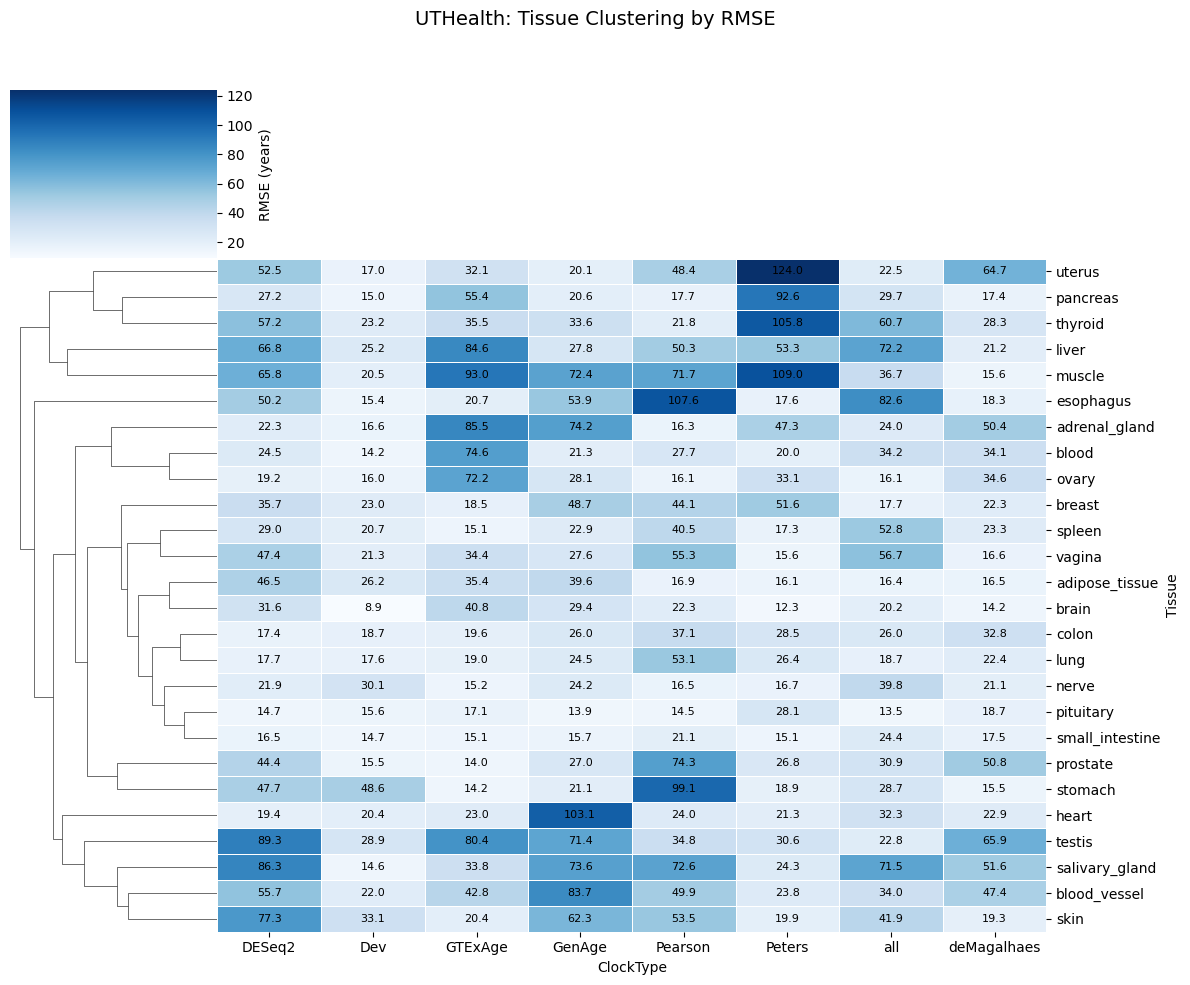

In [31]:
# 1. Load your dataframe (assume it's already loaded as `uth_df`)
# Replace this with your actual DataFrame name if different
uth_df = merged_df2  # If already assigned from your earlier code

# 2. Define age column and clock columns
age_col = 'Age'
clock_cols = uth_df.columns[14:]

# 3. Compute correlation and RMSE
results = []
for col in clock_cols:
    y_true = uth_df[age_col]
    y_pred = uth_df[col]
    corr = y_true.corr(y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    results.append({'Clock': col, 'Correlation': corr, 'RMSE': rmse})

results_df = pd.DataFrame(results)

# 4. Split 'Clock' into 'ClockType' and 'Tissue'
results_df[['ClockType', 'Tissue']] = results_df['Clock'].str.extract(r'^(.*?)_(.+)$')

# 5. Pivot RMSE values into matrix (Tissue x ClockType)
rmse_matrix = results_df.pivot(index='Tissue', columns='ClockType', values='RMSE')

# 6. Create clustermap with low RMSE highlighted
g = sns.clustermap(
    rmse_matrix,
    row_cluster=True,
    col_cluster=False,  # <-- disables clustering of clocks
    metric="euclidean",
    method="average",
    cmap=cmap,
    figsize=(12, 10),
    annot=True,
    fmt=".1f",
    annot_kws={"size": 8, "color": "black"},
    linewidths=0.5,
    cbar_kws={"label": "RMSE (years)"}
)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("UTHealth: Tissue Clustering by RMSE", fontsize=14)
plt.show()